<a href="https://colab.research.google.com/github/gabrielhierro/LinguagensDeProgramacao/blob/main/ExercicioPratico1.3/Exerc%C3%ADcio%20Pr%C3%A1tico_%20An%C3%A1lise%20Visual%20de%20Vendas%20com%20Pandas%20e%20Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Adicionado para corrigir o NameError

# Criação de um dataset fictício de vendas
np.random.seed(42)
datas = pd.date_range(start="2024-01-01", end="2024-06-30", freq="D")
produtos = ["Notebook", "Smartphone", "Fone de Ouvido", "Monitor"]

dados = {
    "Data": np.random.choice(datas, size=300),
    "Produto": np.random.choice(produtos, size=300, p=[0.2, 0.4, 0.25, 0.15]),
    "Quantidade": np.random.randint(1, 6, size=300),
    "Preco_Unitario": 0
}

df = pd.DataFrame(dados)

# Atribuindo preços de acordo com o produto
precos = {"Notebook": 3500, "Smartphone": 2000, "Fone de Ouvido": 150, "Monitor": 1200}
df["Preco_Unitario"] = df["Produto"].map(precos)

print("Dataset criado com sucesso! Primeiras linhas:")
df.head()

Dataset criado com sucesso! Primeiras linhas:


,Data,Produto,Quantidade,Preco_Unitario
0,2024-04-12,Monitor,3,1200
1,2024-06-28,Smartphone,1,2000
2,2024-04-02,Monitor,5,1200
3,2024-01-15,Fone de Ouvido,4,150
4,2024-04-16,Fone de Ouvido,1,150


## Tarefa 1: Faturamento por Produto (Revenue by Product)

In [16]:
# Crie a coluna 'Faturamento_Total'
df['Faturamento_Total'] = df['Quantidade'] * df['Preco_Unitario']

# Agrupe por produto e calcule a soma do faturamento
faturamento_por_produto = df.groupby('Produto')['Faturamento_Total'].sum().reset_index()

print("Faturamento total por produto:")
display(faturamento_por_produto)

Faturamento total por produto:


,Produto,Faturamento_Total
0,Fone de Ouvido,30150
1,Monitor,213600
2,Notebook,686000
3,Smartphone,626000


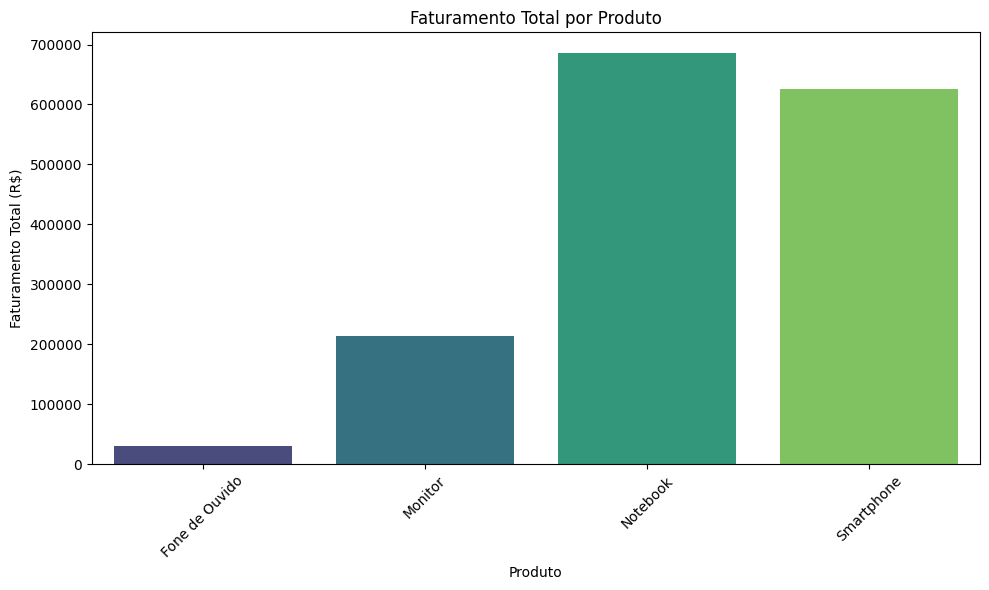

In [17]:
import seaborn as sns # Adicionado para garantir que sns esteja definido
# Gere o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Produto', y='Faturamento_Total', hue='Produto', data=faturamento_por_produto, palette='viridis', legend=False)
plt.title('Faturamento Total por Produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tarefa 2: Evolução das Vendas ao Longo do Tempo (Sales Evolution Over Time)

In [18]:
# Crie a coluna 'Mes'
df['Mes'] = df['Data'].dt.to_period('M')

# Agrupe por mês e calcule o faturamento total
faturamento_mensal = df.groupby('Mes')['Faturamento_Total'].sum().reset_index()

# Converta a coluna 'Mes' de volta para datetime para facilitar a plotagem
faturamento_mensal['Mes'] = faturamento_mensal['Mes'].dt.to_timestamp()

print("Faturamento mensal:")
display(faturamento_mensal)

Faturamento mensal:


,Mes,Faturamento_Total
0,2024-01-01,210300
1,2024-02-01,235950
2,2024-03-01,278450
3,2024-04-01,247650
4,2024-05-01,379650
5,2024-06-01,203750


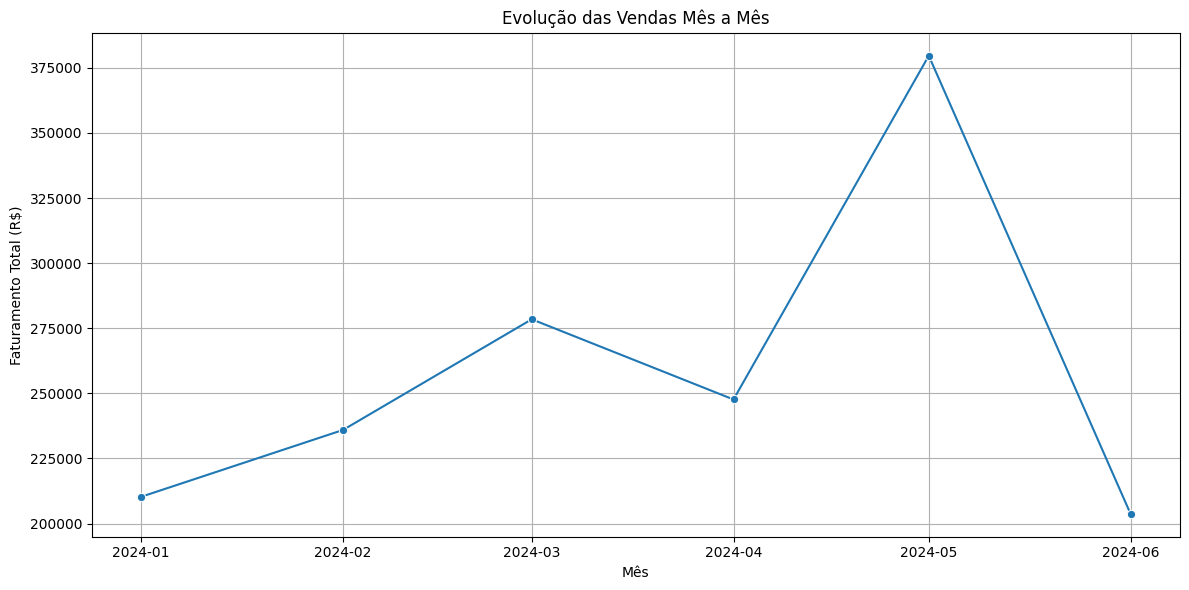

In [19]:
# Gere o gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(x='Mes', y='Faturamento_Total', data=faturamento_mensal, marker='o')
plt.title('Evolução das Vendas Mês a Mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento Total (R$)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Tarefa 3: Distribuição da Quantidade Vendida (Distribution of Quantity Sold)

In [20]:
# Calcule a soma da quantidade vendida por produto
quantidade_por_produto = df.groupby('Produto')['Quantidade'].sum().reset_index()

print("Quantidade total vendida por produto:")
display(quantidade_por_produto)

Quantidade total vendida por produto:


,Produto,Quantidade
0,Fone de Ouvido,201
1,Monitor,178
2,Notebook,196
3,Smartphone,313


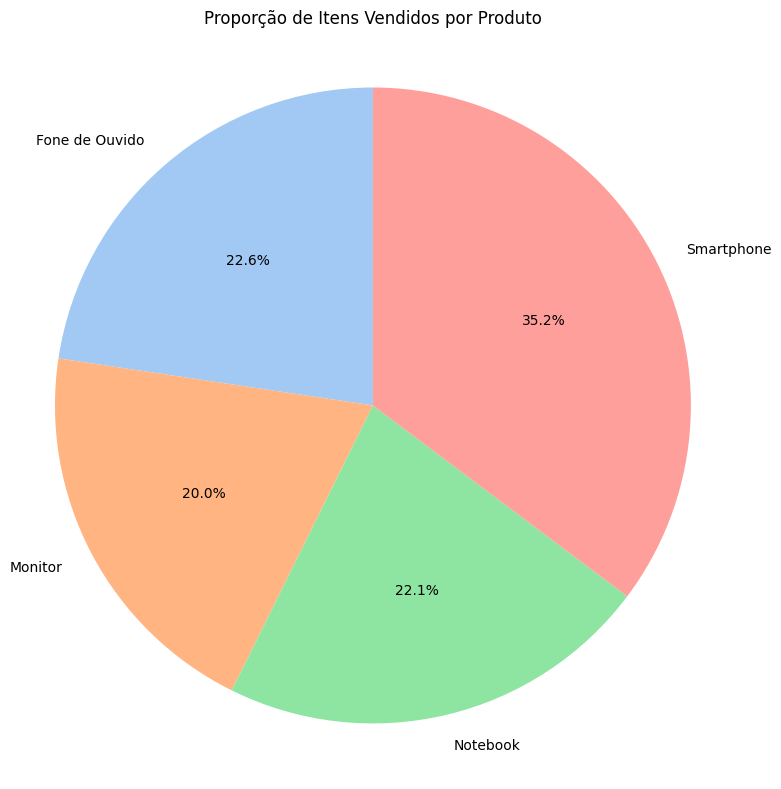

In [21]:
# Gere o gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(quantidade_por_produto['Quantidade'], labels=quantidade_por_produto['Produto'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Proporção de Itens Vendidos por Produto')
plt.axis('equal') # Garante que o gráfico de pizza seja circular
plt.tight_layout()
plt.show()